In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [9]:
import numpy as np
from loaders._gen_binary import generate_data
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier

# Data Generation

In [3]:
_ = generate_data(verbose=True)

Generated dataset with 1995 samples.
Shapes: [(1596, 25), (0, 25), (399, 25)]


# Decision Tree

In [11]:
bacc = []

for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    tscv = TimeSeriesSplit(n_splits=5)

    params = {
        "min_samples_split": np.arange(2, 10 + 1),
        "min_samples_leaf": np.arange(1, 10 + 1)
    }

    search = GridSearchCV(
        estimator=DecisionTreeClassifier(max_depth=3),
        param_grid=params,
        cv=tscv,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)
    y_preds = search.predict(X_test)

    bacc.append(balanced_accuracy_score(y_test, y_preds))

    print(f"Seed {seed} - Test Balanced Accuracy: {bacc[-1]}")

print(f"Mean Test Balanced Accuracy: {np.mean(bacc)}")
print(f"Std Test Balanced Accuracy: {np.std(bacc)}")

Seed 0 - Test Balanced Accuracy: 0.7042713567839196
Seed 1 - Test Balanced Accuracy: 0.6863124560168895
Seed 2 - Test Balanced Accuracy: 0.6446632045981648
Seed 3 - Test Balanced Accuracy: 0.6508529589371981
Seed 4 - Test Balanced Accuracy: 0.6540027137042063
Seed 5 - Test Balanced Accuracy: 0.6845531315974666
Seed 6 - Test Balanced Accuracy: 0.6992462311557789
Seed 7 - Test Balanced Accuracy: 0.724396984924623
Seed 8 - Test Balanced Accuracy: 0.7109343536045106
Seed 9 - Test Balanced Accuracy: 0.6716590440769965
Seed 10 - Test Balanced Accuracy: 0.6817051108095884
Seed 11 - Test Balanced Accuracy: 0.6789539854161428
Seed 12 - Test Balanced Accuracy: 0.6756376075255295
Seed 13 - Test Balanced Accuracy: 0.6430781226419839
Seed 14 - Test Balanced Accuracy: 0.6599110418656079
Seed 15 - Test Balanced Accuracy: 0.6864093537842595
Seed 16 - Test Balanced Accuracy: 0.654070351758794
Seed 17 - Test Balanced Accuracy: 0.6617980072463768
Seed 18 - Test Balanced Accuracy: 0.6843811246796321
Seed 

# Random Forest

In [6]:
bacc = []

for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    tscv = TimeSeriesSplit(n_splits=5)

    params = {
        "n_estimators": [10, 20, 50],
        "min_samples_split": np.arange(2, 10 + 1),
        "min_samples_leaf": np.arange(1, 10 + 1)
    }

    search = GridSearchCV(
        estimator=RandomForestClassifier(max_depth=3),
        param_grid=params,
        cv=tscv,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)
    y_preds = search.predict(X_test)

    bacc.append(balanced_accuracy_score(y_test, y_preds))

    print(f"Seed {seed} - Test Balanced Accuracy: {bacc[-1]}")

print(f"Mean Test Balanced Accuracy: {np.mean(bacc)}")
print(f"Std Test Balanced Accuracy: {np.std(bacc)}")

Seed 0 - Test Balanced Accuracy: 0.7067839195979899
Seed 1 - Test Balanced Accuracy: 0.6765482054890922
Seed 2 - Test Balanced Accuracy: 0.65264192800242
Seed 3 - Test Balanced Accuracy: 0.6514190821256038
Seed 4 - Test Balanced Accuracy: 0.6740539725614352
Seed 5 - Test Balanced Accuracy: 0.6819141449683321
Seed 6 - Test Balanced Accuracy: 0.7193341708542713
Seed 7 - Test Balanced Accuracy: 0.7292587939698493
Seed 8 - Test Balanced Accuracy: 0.7240233588401128
Seed 9 - Test Balanced Accuracy: 0.6717846911594714
Seed 10 - Test Balanced Accuracy: 0.6919568822553896
Seed 11 - Test Balanced Accuracy: 0.6958888609504652
Seed 12 - Test Balanced Accuracy: 0.6945646159263544
Seed 13 - Test Balanced Accuracy: 0.6524850344584738
Seed 14 - Test Balanced Accuracy: 0.6842865758657084
Seed 15 - Test Balanced Accuracy: 0.6990193613276339
Seed 16 - Test Balanced Accuracy: 0.6691708542713568
Seed 17 - Test Balanced Accuracy: 0.6884057971014492
Seed 18 - Test Balanced Accuracy: 0.7167571234735415
Seed 

# XGBoost

In [8]:
bacc = []

for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    tscv = TimeSeriesSplit(n_splits=5)

    params = {
        "n_estimators": [10, 20, 50],
        "min_child_weight": np.arange(1, 10 + 1),
        "subsample": [0.8, 1.0]
    }

    search = GridSearchCV(
        estimator=XGBClassifier(max_depth=3),
        param_grid=params,
        cv=tscv,
        n_jobs=-1,
    )

    search.fit(X_train, y_train)
    y_preds = search.predict(X_test)

    bacc.append(balanced_accuracy_score(y_test, y_preds))

    print(f"Seed {seed} - Test Balanced Accuracy: {bacc[-1]}")

print(f"Mean Test Balanced Accuracy: {np.mean(bacc)}")
print(f"Std Test Balanced Accuracy: {np.std(bacc)}")

Seed 0 - Test Balanced Accuracy: 0.6867085427135677
Seed 1 - Test Balanced Accuracy: 0.6792751583391977
Seed 2 - Test Balanced Accuracy: 0.6508520721992538
Seed 3 - Test Balanced Accuracy: 0.6397192028985508
Seed 4 - Test Balanced Accuracy: 0.6565656565656566
Seed 5 - Test Balanced Accuracy: 0.6718859957776213
Seed 6 - Test Balanced Accuracy: 0.7119095477386934
Seed 7 - Test Balanced Accuracy: 0.6967713567839195
Seed 8 - Test Balanced Accuracy: 0.6949632501006846
Seed 9 - Test Balanced Accuracy: 0.6516685932552646
Seed 10 - Test Balanced Accuracy: 0.6791421679481381
Seed 11 - Test Balanced Accuracy: 0.6786773950213729
Seed 12 - Test Balanced Accuracy: 0.6672116303637003
Seed 13 - Test Balanced Accuracy: 0.6377584385532471
Seed 14 - Test Balanced Accuracy: 0.6793360808162034
Seed 15 - Test Balanced Accuracy: 0.7014583857178778
Seed 16 - Test Balanced Accuracy: 0.6791834170854272
Seed 17 - Test Balanced Accuracy: 0.6601373792270531
Seed 18 - Test Balanced Accuracy: 0.7018694406754108
See

# Ablation Study

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [13]:
pack = generate_data(seed=0, verbose=True)
X_train, y_train = pack["train"]
X_test, y_test = pack["test"]

Generated dataset with 1995 samples.
Shapes: [(1596, 25), (0, 25), (399, 25)]


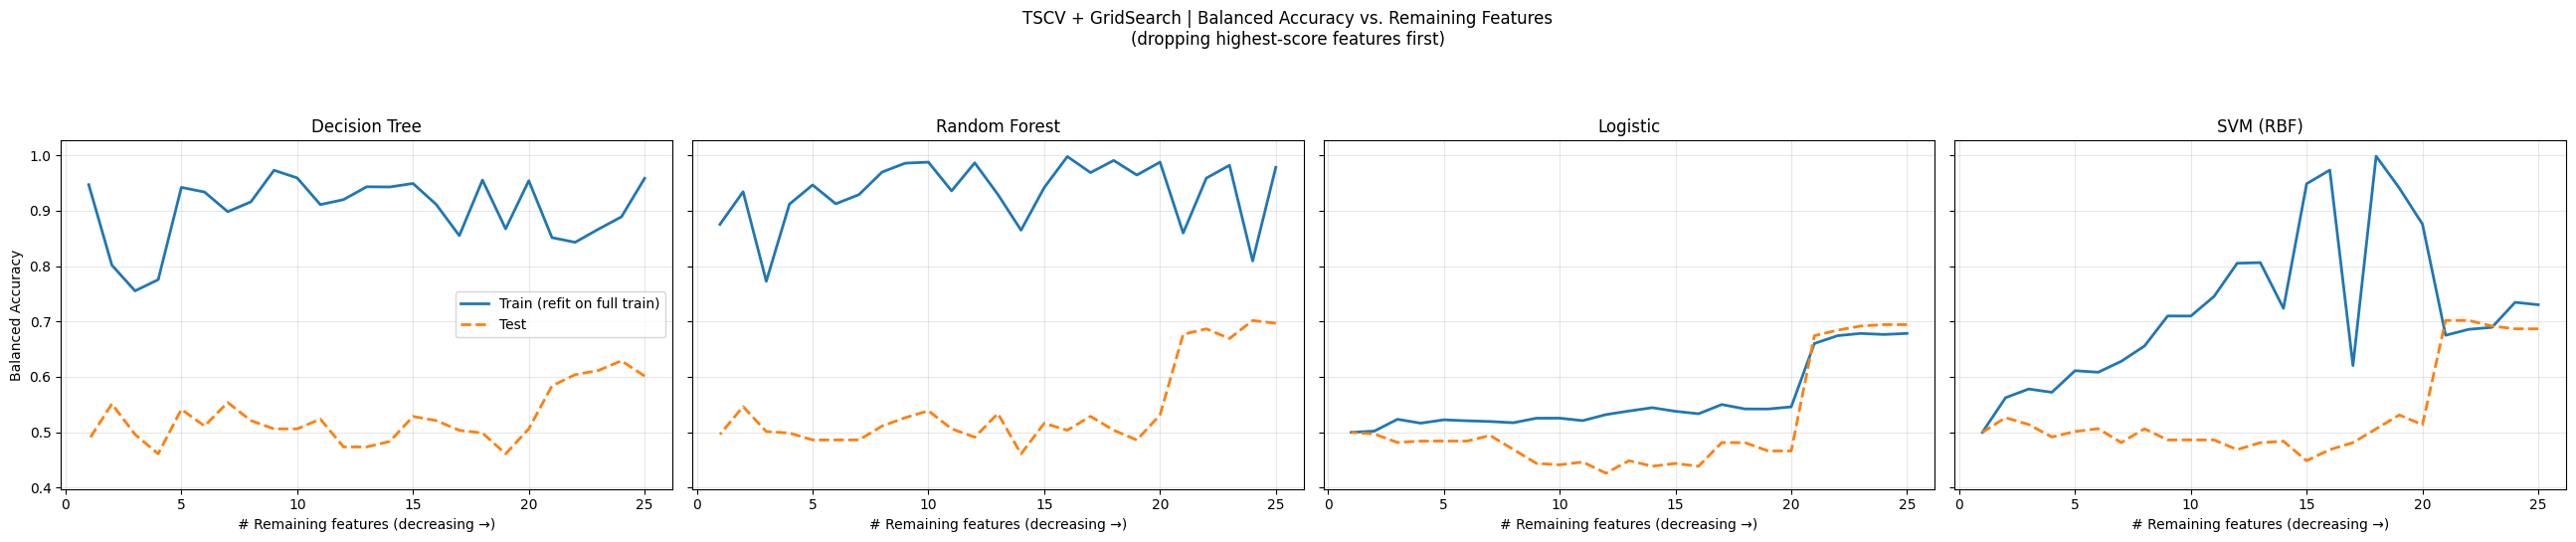

Top 10 features by MI (index: score):
 1. 10: 0.0839
 2. 0: 0.0726
 3. 20: 0.0672
 4. 15: 0.0597
 5. 5: 0.0596
 6. 6: 0.0221
 7. 21: 0.0196
 8. 1: 0.0178
 9. 22: 0.0165
10. 2: 0.0128


In [17]:
# === TimeSeriesSplit + GridSearchCV + progressive feature culling (balanced accuracy) ===
# Assumes you already have:
# pack = generate_data(seed=seed)
# X_train, y_train = pack["train"]
# X_test,  y_test  = pack["test"]

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# --- 0) y to (n_samples,) ---
y_train_1d = np.asarray(y_train).ravel()
y_test_1d  = np.asarray(y_test).ravel()

# --- 1) Feature "usefulness" scores on TRAIN (Mutual Information) ---
mi_scores = mutual_info_classif(X_train, y_train_1d, random_state=0, discrete_features="auto")
order_desc = np.argsort(mi_scores)[::-1]   # high -> low
n_features = X_train.shape[1]

# --- 2) TSCV and model+param grids ---
tscv = TimeSeriesSplit(n_splits=5)

random_state = 0
models = {
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=random_state))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(random_state=random_state, n_jobs=-1))
    ]),
    "Logistic": Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            penalty="l2", solver="lbfgs", max_iter=2000, random_state=random_state))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", SVC(kernel="rbf", probability=False, random_state=random_state))
    ]),
}

# Param grids (note: keys match pipeline step names)
param_grids = {
    "Decision Tree": {
        "clf__min_samples_split": np.arange(2, 10 + 1),
        "clf__min_samples_leaf":  np.arange(1, 10 + 1),
    },
    "Random Forest": {
        "clf__n_estimators":      [10, 20, 50],
        "clf__min_samples_split": np.arange(2, 10 + 1),
        "clf__min_samples_leaf":  np.arange(1, 10 + 1),
    },
    "Logistic": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        # (penalty='l2', solver='lbfgs' already set)
    },
    "SVM (RBF)": {
        "clf__C":    [0.1, 1.0, 10.0],
        "clf__gamma": ["scale", 0.01, 0.1],
    },
}

# --- 3) Progressive culling: drop highest-score features first ---
remaining_counts = []
results = {name: {"train": [], "test": []} for name in models}

for r in range(0, n_features):          # r = number of top features removed
    keep_idx = order_desc[r:]            # keep the rest
    k = len(keep_idx)
    remaining_counts.append(k)

    Xtr = X_train[:, keep_idx]
    Xte = X_test[:, keep_idx]

    for name in models.keys():
        pipe = models[name]
        grid = param_grids[name]

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="balanced_accuracy",
            cv=tscv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs.fit(Xtr, y_train_1d)
        best_est = gs.best_estimator_

        # Evaluate on the full train and on test
        ytr_pred = best_est.predict(Xtr)
        yte_pred = best_est.predict(Xte)

        ba_tr = balanced_accuracy_score(y_train_1d, ytr_pred)
        ba_te = balanced_accuracy_score(y_test_1d,  yte_pred)

        results[name]["train"].append(ba_tr)
        results[name]["test"].append(ba_te)

# --- 4) Plot: 4 subplots horizontally, x-axis = # remaining features (decreasing →) ---
fig, axes = plt.subplots(1, 4, figsize=(26, 5), sharey=True)
fig.suptitle("TSCV + GridSearch | Balanced Accuracy vs. Remaining Features\n(dropping highest-score features first)", y=1.08)

for ax, (name, curves) in zip(axes, results.items()):
    ax.plot(remaining_counts, curves["train"], label="Train (refit on full train)", linewidth=2)
    ax.plot(remaining_counts, curves["test"],  label="Test", linewidth=2, linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("# Remaining features (decreasing →)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Balanced Accuracy")
axes[0].legend(loc="best")

plt.tight_layout()
plt.show()

# --- 5) (Optional) Inspect the ranking and MI scores ---
print("Top 10 features by MI (index: score):")
for i, fidx in enumerate(order_desc[:10]):
    print(f"{i+1:>2}. {fidx}: {mi_scores[fidx]:.4f}")


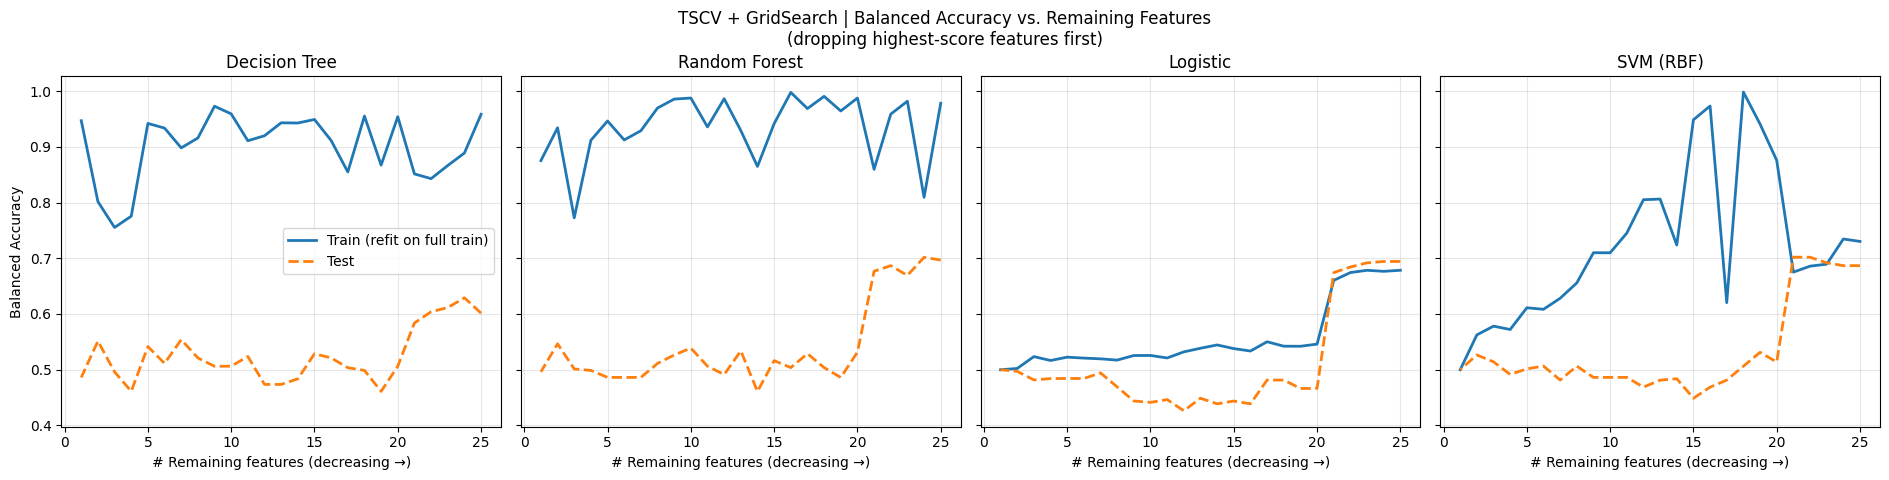

In [ ]:
# --- 4) Plot: 4 subplots horizontally, x-axis = # remaining features (decreasing →) ---
fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
fig.suptitle("TSCV + GridSearch | Balanced Accuracy vs. Remaining Features\n(dropping highest-score features first)", y=0.95)

for ax, (name, curves) in zip(axes, results.items()):
    ax.plot(remaining_counts, curves["train"], label="Train (refit on full train)", linewidth=2)
    ax.plot(remaining_counts, curves["test"],  label="Test", linewidth=2, linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("# Remaining features (decreasing →)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Balanced Accuracy")
axes[0].legend(loc="best")

plt.tight_layout()
plt.show()